In [9]:
import random

import torch
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm 
import matplotlib.colors as colors
from matplotlib.ticker import FuncFormatter, MultipleLocator
import seaborn as sns

from retina import train, models, dataset, analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
root = "/home/luketaylor/PycharmProjects/RetinalModel"

In [3]:
train_dataset = dataset.PatchNaturalDataset(root="/home/datasets/natural", train=True, temp_len=40, kernel=20, flip=True, n_frame_ext=2)

In [4]:
model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")

## LIF example

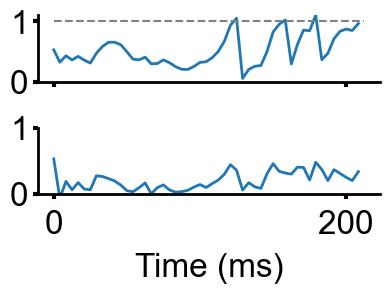

In [5]:
random.seed(0)
torch.manual_seed(2) # 58
x, y = train_dataset[300]

with torch.no_grad():
    output, spikes, mem, abs_rec, input_current = model(x.unsqueeze(0).cuda(), mode="val")
    output = output.cpu().detach()
    spikes = spikes.cpu().detach()
    mem = mem.cpu().detach()
    abs_rec = abs_rec.cpu().detach()
    input_current = input_current.cpu().detach()
    
def plot_mem_and_spikes(unit_idx, ax):
    ax.plot(mem[0, unit_idx], linewidth=2)
    #ax.plot(1*spikes[0, unit_idx, :])
    #spike_bins = (torch.arange(len(spikes[0, unit_idx, :]))*spikes[0, unit_idx, :]).nonzero().flatten()
    #ax.scatter(spike_bins, 2*torch.ones(len(spike_bins)), c="black")
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 24
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_ylabel("", fontsize=labelsize, labelpad=8)
    ax.set_xticks([0, 48])
    ax.set_xticklabels([0, 200])
    ax.set_ylim([0, 1.1])
    ax.plot([0,  mem.shape[2] ], [1, 1], "--", c="Gray")
    
def plot_current(unit_idx, ax):
    current = input_current[0, unit_idx, :, 0, 0] + abs_rec[0, unit_idx, :]
    ax.plot(current, linewidth=2)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    labelsize = 24
    ax.xaxis.set_tick_params(width=3, labelsize=labelsize, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=labelsize)
    ax.set_ylabel("", fontsize=labelsize, labelpad=8)
    ax.set_xlabel("Time (ms)", fontsize=labelsize, labelpad=8)
    ax.set_ylim([0, 1])
    
unit_idx = 25
fig, axs = plt.subplots(2, 1, figsize=(4, 3), sharex=True)
plot_mem_and_spikes(unit_idx, axs[0])
plot_current(unit_idx, axs[1])
fig.tight_layout()

## Input output/predicted frames

In [146]:
random.seed(7)
torch.manual_seed(2) # 58
x, y = train_dataset[300]

with torch.no_grad():
    output, spikes, mem, abs_rec, input_current = model(x.unsqueeze(0).cuda(), mode="val")
    output = output.cpu().detach()
    spikes = spikes.cpu().detach()
    mem = mem.cpu().detach()
    abs_rec = abs_rec.cpu().detach()
    input_current = input_current.cpu().detach()

In [147]:
x_trim = x[0, 32:]
y_trim = output[0, 0, :]

In [149]:
def plot_frame(frame, ax):
    ax.imshow(frame, vmin=-1, vmax=1, cmap="Greys")
    ax.spines["right"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

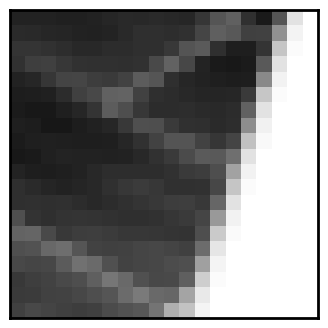

In [150]:
# Input frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_frame(x_trim[0], ax)

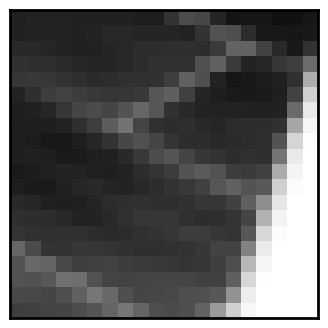

In [151]:
# Output frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_frame(x_trim[30+15], ax)

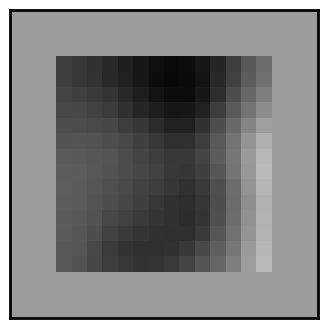

In [152]:
# Predicted frame
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_frame(y_trim[15], ax)

## Supplementary

In [23]:
all_spike_stats = analysis.AllDatasetSpikeStats(root)

/home/luketaylor/miniconda3/envs/retina/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


subclip_len=72
torch.Size([60, 1, 72, 30, 30])
subclip_len=180
torch.Size([10, 1, 180, 20, 20])
subclip_len=1440
torch.Size([2, 1, 1440, 20, 20])
subclip_len=1056
torch.Size([1, 1, 1056, 80, 80])
subclip_len=1200
torch.Size([1, 1, 1200, 80, 80])


/home/luketaylor/miniconda3/envs/retina/lib/python3.8/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


subclip_len=72


In [119]:
def plot_fano_factors(fanos, ax):
    list_data = []
    for v in fanos:
        list_data.append({"data": "exp", "y": v.item()})
    data_df = pd.DataFrame(list_data)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.xaxis.set_tick_params(width=3, labelsize=16, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    ax.set_xlabel("Fano Factor", fontsize=20, labelpad=10)
    
    sns.histplot(data_df, x="y", stat="probability", bins=[0, 0.25, 0.5, 0.75, 1, 1.25], ax=ax)

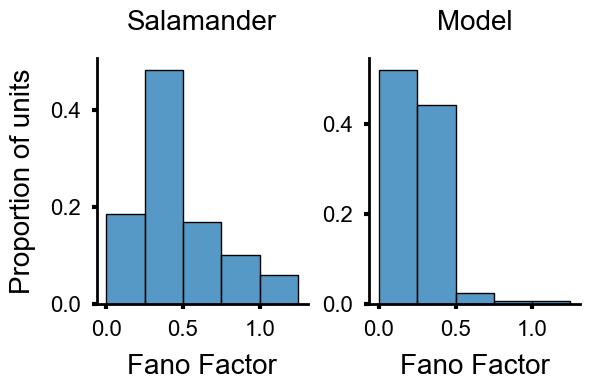

In [135]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4))
plot_fano_factors(all_spike_stats.sal_img_stats.exp_stats.fano, axs[0])
plot_fano_factors(all_spike_stats.sal_img_stats.pred_model_stats.fano, axs[1])
axs[0].set_ylabel("Proportion of units", fontsize=20, labelpad=10)
axs[1].set_ylabel("")
axs[0].set_title("Salamander", fontsize=20, pad=20)
axs[1].set_title("Model", fontsize=20, pad=20)
fig.tight_layout()
#plt.savefig(f"{root}/figures/model/fano_factors.svg", format="svg", transparent=False, bbox_inches="tight")

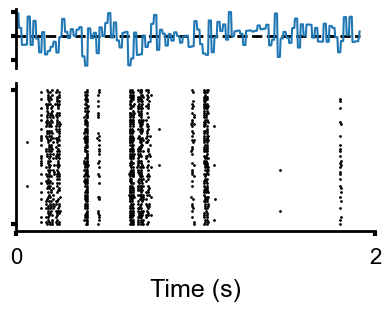

In [131]:
def plot_spike_precision(precision_query, intesity_ax, raster_ax):
    # Intensity plot
    intesity_ax.plot([0, len(precision_query.flicker_clip)], [0, 0], "--", c="black", linewidth=2)
    intesity_ax.plot(precision_query.flicker_clip)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    intesity_ax.set_yticks([-2, 0, 2])
    intesity_ax.set_yticklabels(["", "", ""])
    intesity_ax.set_xlim([0, 500])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    # intesity_ax.set_ylabel("Intensity (mean)", fontsize=20, labelpad=2)
    #intesity_ax.set_ylabel("Intensity", fontsize=18, labelpad=35, rotation=0)
    
    # Raster plot
    raster_x, raster_y = precision_query.get_spike_coo(84)
    raster_ax.scatter(raster_x, raster_y+1, s=1, c="black")
    raster_ax.spines["top"].set_visible(False)
    raster_ax.spines["right"].set_visible(False)
    raster_ax.spines["bottom"].set_linewidth(2)
    raster_ax.spines["left"].set_linewidth(2)
    raster_ax.xaxis.set_tick_params(width=3, labelsize=16, pad=8)
    raster_ax.yaxis.set_tick_params(width=3, labelsize=16, pad=8)
    raster_ax.set_yticks([1, 60])
    raster_ax.set_yticklabels(["", ""])
    raster_ax.set_xticks([0, 500])
    raster_ax.set_xticklabels([0, 2])
    raster_ax.set_xlabel("Time (s)", fontsize=18, labelpad=8)
    #raster_ax.set_ylabel("Trial", fontsize=18, labelpad=2)
    raster_ax.set_xlim([0, 500])


precision_query = analysis.PrecisionQuery(root, duration_ms=2000, n_trials=60, lum=1)


fig = plt.figure(constrained_layout=True, figsize=(3.8, 3))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[0.4, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
raster_ax = fig.add_subplot(spec[1]) 

plot_spike_precision(precision_query, intesity_ax, raster_ax)
#plt.savefig(f"{root}/figures/spike_fig/spike_precision.svg", format="svg", transparent=False, bbox_inches="tight")